In [1]:
# load csv files from a link, using pandas:
# this is the link to the files:
# https://drive.google.com/file/d/1jqDJdszLC1lDEP502acYC8q4CkdlXk7y/view?usp=sharing (Poorav)
# https://drive.google.com/file/d/1n3A2yZWakJAQX7AXX2KRe_J8vypTuCBm/view?usp=sharing (Orit)
# https://drive.google.com/file/d/1sVhTGC94ggct5U8NtjwWc5LbvWPPrjwz/view?usp=sharing (Aditya)
# https://drive.google.com/file/d/1CAUpJMEYI5jIyoPpT4W1k0VWmvrCkych/view?usp=sharing (Fareya)

import pandas as pd
import datetime
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from patsy import dmatrices

# poorav_df = pd.read_csv('https://drive.google.com/file/d/1jqDJdszLC1lDEP502acYC8q4CkdlXk7y') # Poorav
# orit_df = pd.read_csv('https://drive.google.com/file/d/1n3A2yZWakJAQX7AXX2KRe_J8vypTuCBm') # Orit
# aditya_df = pd.read_csv('https://drive.google.com/file/d/1sVhTGC94ggct5U8NtjwWc5LbvWPPrjwz') # Aditya
# fareya_df = pd.read_csv('https://drive.google.com/file/d/1CAUpJMEYI5jIyoPpT4W1k0VWmvrCkych') # Fareya

# Load data from CSV files on google drive:
poorav_df =  pd.read_csv('https://drive.google.com/uc?export=download&id=1jqDJdszLC1lDEP502acYC8q4CkdlXk7y')
orit_df = pd.read_csv('https://drive.google.com/uc?export=download&id=1n3A2yZWakJAQX7AXX2KRe_J8vypTuCBm')
aditya_df = pd.read_csv('https://drive.google.com/uc?export=download&id=1sVhTGC94ggct5U8NtjwWc5LbvWPPrjwz')
fareya_df = pd.read_csv('https://drive.google.com/uc?export=download&id=1CAUpJMEYI5jIyoPpT4W1k0VWmvrCkych')

# Select only rows that match Poorav datetimes:
poorav_df = poorav_df[poorav_df['date_time'].str.contains('2024-07-23_T20-35-26|'+
                                                          '2024-07-23_T20-36-38|'+
                                                          '2024-07-23_T20-37-59|'+
                                                          '2024-07-23_T20-40-58|'+
                                                          '2024-07-23_T20-42-19|'+
                                                          '2024-07-23_T21-06-18|'+
                                                          '2024-07-23_T23-07-15')]

# Poorav output files:
# -rw-r--r-- 1 prawat2 domain users  54K Jul 24 18:18 ./MISA-pytorch/slurm_logs/out5940592-4294967294.out MISI:0.05511028828647965
# -rw-r--r-- 1 prawat2 domain users  54K Jul 24 18:39 ./MISA-pytorch/slurm_logs/out5940586-4294967294.out MISI:0.08533364049672958
# -rw-r--r-- 1 prawat2 domain users  54K Jul 25 06:32 ./MISA-pytorch/slurm_logs/out5940615-4294967294.out MISI:0.09330128036246113
# -rw-r--r-- 1 prawat2 domain users  54K Jul 25 11:19 ./MISA-pytorch/slurm_logs/out5940600-4294967294.out MISI:0.0821143614752742
# -rw-r--r-- 1 prawat2 domain users  54K Jul 25 20:20 ./MISA-pytorch/slurm_logs/out5940628-4294967294.out MISI:0.034881723712886975
# -rw-r--r-- 1 prawat2 domain users  54K Jul 26 05:40 ./MISA-pytorch/slurm_logs/out5940622-4294967294.out MISI:0.026206004050258185
# -rw-r--r-- 1 prawat2 domain users  54K Jul 26 06:05 ./MISA-pytorch/slurm_logs/out5940619-4294967294.out MISI:0.03733535392310585


poorav_df['date_time'] = pd.to_datetime(poorav_df['date_time'], format='%Y-%m-%d_T%H-%M-%S')
poorav_df['end_time'] = poorav_df['date_time'] + pd.to_timedelta(poorav_df['run_time'], unit='s')
poorav_df.sort_values(by=['end_time'])

poorav_df['MISI'] = [0.05511028828647965, 0.08533364049672958, 0.09330128036246113, 0.0821143614752742, 0.034881723712886975, 0.026206004050258185, 0.03733535392310585]
poorav_df['Epoch'] = [100, 800, 800, 300, 300, 200, 800]

# Select only rows that match Orit datetimes:
orit_df = orit_df[orit_df['date_time'].str.contains('2024-07-23_T20-35-51|'+
                                                    '2024-07-23_T20-36-59|'+
                                                    '2024-07-23_T20-37-33|'+
                                                    '2024-07-23_T20-41-16|'+
                                                    '2024-07-23_T20-42-21|'+
                                                    '2024-07-23_T20-43-12|'+
                                                    '2024-07-23_T20-44-18')]

# Orit output files:
# -rw-r--r-- 1 oyohannes1 domain users  54K Jul 24 17:40 ./MISA-pytorch/slurm_logs/out5940595-4294967294.out MISI: 0.07870384820189154
# -rw-r--r-- 1 oyohannes1 domain users  54K Jul 24 18:11 ./MISA-pytorch/slurm_logs/out5940599-4294967294.out MISI: 0.015833844092065636
# -rw-r--r-- 1 oyohannes1 domain users  54K Jul 24 22:42 ./MISA-pytorch/slurm_logs/out5940623-4294967294.out MISI: 0.0260693464608147
# -rw-r--r-- 1 oyohannes1 domain users  54K Jul 25 05:53 ./MISA-pytorch/slurm_logs/out5940626-4294967294.out MISI: 0.0431961913408233
# -rw-r--r-- 1 oyohannes1 domain users  54K Jul 25 11:39 ./MISA-pytorch/slurm_logs/out5940589-4294967294.out MISI: 0.05991324746240559
# -rw-r--r-- 1 oyohannes1 domain users  54K Jul 26 05:35 ./MISA-pytorch/slurm_logs/out5940620-4294967294.out MISI: 0.08066819245156975
# -rw-r--r-- 1 oyohannes1 domain users  54K Jul 26 06:06 ./MISA-pytorch/slurm_logs/out5940617-4294967294.out MISI: 0.07091928812568009

orit_df['date_time'] = pd.to_datetime(orit_df['date_time'], format='%Y-%m-%d_T%H-%M-%S')
orit_df['end_time'] = orit_df['date_time'] + pd.to_timedelta(orit_df['run_time'], unit='s')
orit_df.sort_values(by=['end_time'])

orit_df['MISI'] = [0.07870384820189154, 0.015833844092065636, 0.0260693464608147, 0.0431961913408233, 0.05991324746240559, 0.08066819245156975, 0.07091928812568009]
orit_df['Epoch'] = [200, 500, 200, 800, 100, 100, 800]

# Select only rows that match Aditya datetimes:
aditya_df = aditya_df[aditya_df['date_time'].str.contains('2024-07-23_T20-34-34|'+
                                                          '2024-07-23_T20-35-34|'+
                                                          '2024-07-23_T20-36-15|'+
                                                          '2024-07-23_T20-37-16|'+
                                                          '2024-07-23_T20-38-14|'+
                                                          '2024-07-23_T20-38-53')]

# Aditya output files:
# -rw-r--r-- 1 asule1 domain users  54K Jul 24 18:24 ./MISA-pytorch/slurm_logs/out5940604-4294967294.out MISI: 0.12751751806972889
# -rw-r--r-- 1 asule1 domain users  54K Jul 25 06:12 ./MISA-pytorch/slurm_logs/out5940602-4294967294.out MISI: 0.07213794022548879
# -rw-r--r-- 1 asule1 domain users  54K Jul 25 06:21 ./MISA-pytorch/slurm_logs/out5940587-4294967294.out MISI: 0.10337325817422945
# -rw-r--r-- 1 asule1 domain users  54K Jul 25 11:25 ./MISA-pytorch/slurm_logs/out5940584-4294967294.out MISI: 0.0468505454312019
# -rw-r--r-- 1 asule1 domain users  54K Jul 25 11:50 ./MISA-pytorch/slurm_logs/out5940591-4294967294.out MISI: 0.05001349333486675
# -rw-r--r-- 1 asule1 domain users  54K Jul 25 18:15 ./MISA-pytorch/slurm_logs/out5940597-4294967294.out MISI: 0.047784075324151964

aditya_df['date_time'] = pd.to_datetime(aditya_df['date_time'], format='%Y-%m-%d_T%H-%M-%S')
aditya_df['end_time'] = aditya_df['date_time'] + pd.to_timedelta(aditya_df['run_time'], unit='s')
aditya_df.sort_values(by=['end_time'])

aditya_df['MISI'] = [0.12751751806972889, 0.07213794022548879, 0.10337325817422945, 0.0468505454312019, 0.05001349333486675, 0.047784075324151964]
aditya_df['Epoch'] = [800, 100, 100, 100, 800, 800]

# Select only rows that match Fareya datetimes:
fareya_df = fareya_df[fareya_df['date_time'].str.contains('2024-07-23_T20-33-48|'+
                                                          '2024-07-23_T20-34-47|'+
                                                          '2024-07-23_T20-41-34|'+
                                                          '2024-07-23_T20-42-34|'+
                                                          '2024-07-23_T20-43-35|'+
                                                          '2024-07-25_T01-31-00')]

# Fareya output files:
# -rw-r--r-- 1 fborhan1 domain users  54K Jul 24 22:44 ./MISA-pytorch/slurm_logs/out5940621-4294967294.out MISI: 0.06788988042500471
# -rw-r--r-- 1 fborhan1 domain users  54K Jul 25 05:40 ./MISA-pytorch/slurm_logs/out5940618-4294967294.out MISI: 0.04159911461191194
# -rw-r--r-- 1 fborhan1 domain users  53K Jul 25 06:39 ./MISA-pytorch/slurm_logs/out5940624-4294967294.out MISI: 0.22741175209372003
# -rw-r--r-- 1 fborhan1 domain users  54K Jul 25 12:18 ./MISA-pytorch/slurm_logs/out5940583-4294967294.out MISI: 0.1145756508416124
# -rw-r--r-- 1 fborhan1 domain users  54K Jul 26 06:38 ./MISA-pytorch/slurm_logs/out5940585-4294967294.out MISI: 0.07310261341701323
# -rw-r--r-- 1 fborhan1 domain users  54K Jul 26 16:26 ./MISA-pytorch/slurm_logs/out5940630-4294967294.out MISI: 0.100745580668897

fareya_df['date_time'] = pd.to_datetime(fareya_df['date_time'], format='%Y-%m-%d_T%H-%M-%S')
fareya_df['end_time'] = fareya_df['date_time'] + pd.to_timedelta(fareya_df['run_time'], unit='s')
fareya_df.sort_values(by=['end_time'])

fareya_df['MISI'] = [0.06788988042500471, 0.04159911461191194, 0.22741175209372003, 0.1145756508416124, 0.07310261341701323, 0.100745580668897]
fareya_df['Epoch'] = [100, 800, 400, 800, 100, 800]


# print(poorav_df.head())
# print(orit_df.head())
# print(aditya_df.head())
# print(fareya_df.head())

# Concatenate dataframes:
mp_df = pd.concat([poorav_df, orit_df, aditya_df, fareya_df])

dtype_dict = {
    'experimenter': 'category',
    'seed': 'category',
    'fused': 'category',
    'foreach': 'category',
    'GPU': 'category',
    'weights': 'category',
    'patience': 'int64',
    'batch_size': 'int64',
    'epochs_completed': 'int64',
    'learning_rate': 'float64',
    'dataset_filename': 'str',
    'running_data': 'str',
    'beta1': 'float64',
    'beta2': 'float64',
    'run_time': 'float64',
    'MISI': 'float64',
    'Epoch': 'float64'
}
mp_df = mp_df.astype(dtype_dict)

mp_df['MxE'] = mp_df['MISI'] * mp_df['Epoch']
mp_df['MxE_log'] = np.log10(mp_df['MxE'])

mp_df['MISI_log'] = np.log10(mp_df['MISI'])
mp_df['Epoch_log'] = np.log10(mp_df['Epoch'])

mp_df['LocalOS_bool'] = pd.Categorical((mp_df['experimenter'].str.contains('fborhan1|oyohannes1')))
mp_df['LocalOS'] = pd.Categorical(mp_df['LocalOS_bool'].replace({False:"PC", True:"Mac"}))

mp_df['Foreach_Fused'] = pd.Categorical(2 * mp_df['fused'].astype('float64') + mp_df['foreach'].astype('float64') - 1)

# Adjust scale and offset
mp_df['Learning_rate_log'] = np.log10(mp_df['learning_rate']) - (-2.0)
mp_df['Batch_size_log'] = np.log10(mp_df['batch_size']) - 2.5
mp_df['Batch_size_log'] = 2 * mp_df['Batch_size_log'] / (mp_df['Batch_size_log'].max() - mp_df['Batch_size_log'].min() )
mp_df['Patience_log'] = np.log10(mp_df['patience']) - 1.5
mp_df['Patience_log'] = 2 * mp_df['Patience_log'] / (mp_df['Patience_log'].max() - mp_df['Patience_log'].min() )
mp_df['beta1_0'] = 2 * (mp_df['beta1'] - 0.8) / .30
mp_df['beta2_0'] = 2 * (mp_df['beta2'] - 0.9) / .18
mp_df['run_time_log'] = np.log10(mp_df['run_time'])

# # Sort rows by date_time:
# mp_df = mp_df.sort_values(by=['date_time'])
# mp_df[['Learning_rate_log','Batch_size_log']]
# print all column names in dataframe:
print(mp_df.columns)


Index(['experimenter', 'date_time', 'batch_size', 'learning_rate', 'weights',
       'seed', 'patience', 'beta1', 'beta2', 'fused', 'foreach', 'run_time',
       'epochs_completed', 'GPU', 'dataset_filename', 'running_data',
       'end_time', 'MISI', 'Epoch', 'MxE', 'MxE_log', 'MISI_log', 'Epoch_log',
       'LocalOS_bool', 'LocalOS', 'Foreach_Fused', 'Learning_rate_log',
       'Batch_size_log', 'Patience_log', 'beta1_0', 'beta2_0', 'run_time_log'],
      dtype='object')


/tmp/ipykernel_2053287/477402613.py:162: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  mp_df['LocalOS'] = pd.Categorical(mp_df['LocalOS_bool'].replace({False:"PC", True:"Mac"}))


In [2]:
# print(mp_df.columns)
# mp_df[['MISI_Seed14']]

In [3]:
print(mp_df.columns)
mp_df[['learning_rate', 'batch_size', 'beta1', 'beta2', 'fused', 'foreach', 'patience', 'LocalOS', 'GPU', 'MISI', 'Epoch', 'MxE']]

Index(['experimenter', 'date_time', 'batch_size', 'learning_rate', 'weights',
       'seed', 'patience', 'beta1', 'beta2', 'fused', 'foreach', 'run_time',
       'epochs_completed', 'GPU', 'dataset_filename', 'running_data',
       'end_time', 'MISI', 'Epoch', 'MxE', 'MxE_log', 'MISI_log', 'Epoch_log',
       'LocalOS_bool', 'LocalOS', 'Foreach_Fused', 'Learning_rate_log',
       'Batch_size_log', 'Patience_log', 'beta1_0', 'beta2_0', 'run_time_log'],
      dtype='object')


,learning_rate,batch_size,beta1,beta2,fused,foreach,patience,LocalOS,GPU,MISI,Epoch,MxE
8,0.100,500,0.95,0.81,True,False,100,PC,A40,0.055110,100.0,5.511029
9,0.001,500,0.80,0.99,False,False,10,PC,A40,0.085334,800.0,68.266912
11,0.001,200,0.95,0.99,False,False,100,PC,A40,0.093301,800.0,74.641024
12,0.100,500,0.65,0.99,False,True,100,PC,RTX,0.082114,300.0,24.634308
13,0.010,316,0.80,0.90,False,True,32,PC,RTX,0.034882,300.0,10.464517
16,0.010,200,0.65,0.81,False,False,10,PC,RTX,0.026206,200.0,5.241201
17,0.001,200,0.95,0.81,True,False,32,PC,RTX,0.037335,800.0,29.868283
8,0.100,500,0.65,0.99,False,False,32,Mac,A40,0.078704,200.0,15.740770
9,0.010,500,0.95,0.99,True,False,100,Mac,A40,0.015834,500.0,7.916922
11,0.010,316,0.80,0.90,False,True,32,Mac,A40,0.026069,200.0,5.213869


In [4]:
mp_df

,experimenter,date_time,batch_size,learning_rate,weights,seed,patience,beta1,beta2,fused,...,Epoch_log,LocalOS_bool,LocalOS,Foreach_Fused,Learning_rate_log,Batch_size_log,Patience_log,beta1_0,beta2_0,run_time_log
8,prawat2,2024-07-23 20:36:38,500,0.100,wpca,7,100,0.95,0.81,True,...,2.000000,False,PC,1.0,1.0,1.000000,1.0000,1.0,-1.0,4.892204
9,prawat2,2024-07-23 20:35:26,500,0.001,wpca,7,10,0.80,0.99,False,...,2.903090,False,PC,-1.0,-1.0,1.000000,-1.0000,0.0,1.0,4.899693
11,prawat2,2024-07-23 20:40:58,200,0.001,wpca,7,100,0.95,0.99,False,...,2.903090,False,PC,-1.0,-1.0,-1.000000,1.0000,1.0,1.0,5.085591
12,prawat2,2024-07-23 20:37:59,500,0.100,wpca,7,100,0.65,0.99,False,...,2.477121,False,PC,0.0,1.0,1.000000,1.0000,-1.0,1.0,5.143356
13,prawat2,2024-07-23 23:07:15,316,0.010,wpca,7,32,0.80,0.90,False,...,2.477121,False,PC,0.0,0.0,-0.001573,0.0103,0.0,0.0,5.211165
16,prawat2,2024-07-23 21:06:18,200,0.010,wpca,7,10,0.65,0.81,False,...,2.301030,False,PC,-1.0,0.0,-1.000000,-1.0000,-1.0,-1.0,5.308598
17,prawat2,2024-07-23 20:42:19,200,0.001,wpca,7,32,0.95,0.81,True,...,2.903090,False,PC,1.0,-1.0,-1.000000,0.0103,1.0,-1.0,5.314773
8,oyohannes1,2024-07-23 20:36:59,500,0.100,wpca,7,32,0.65,0.99,False,...,2.301030,True,Mac,-1.0,1.0,1.000000,0.0103,-1.0,1.0,4.879098
9,oyohannes1,2024-07-23 20:37:33,500,0.010,wpca,7,100,0.95,0.99,True,...,2.698970,True,Mac,1.0,0.0,1.000000,1.0000,1.0,1.0,4.889690
11,oyohannes1,2024-07-23 20:43:12,316,0.010,wpca,7,32,0.80,0.90,False,...,2.301030,True,Mac,0.0,0.0,-0.001573,0.0103,0.0,0.0,4.970684


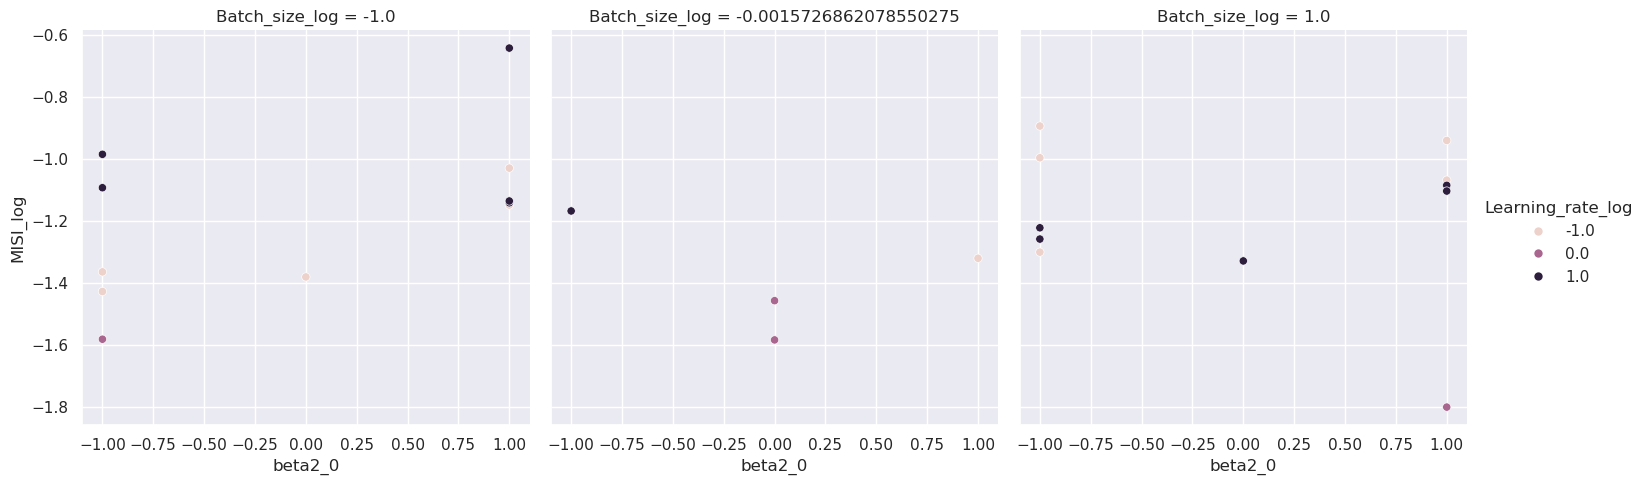

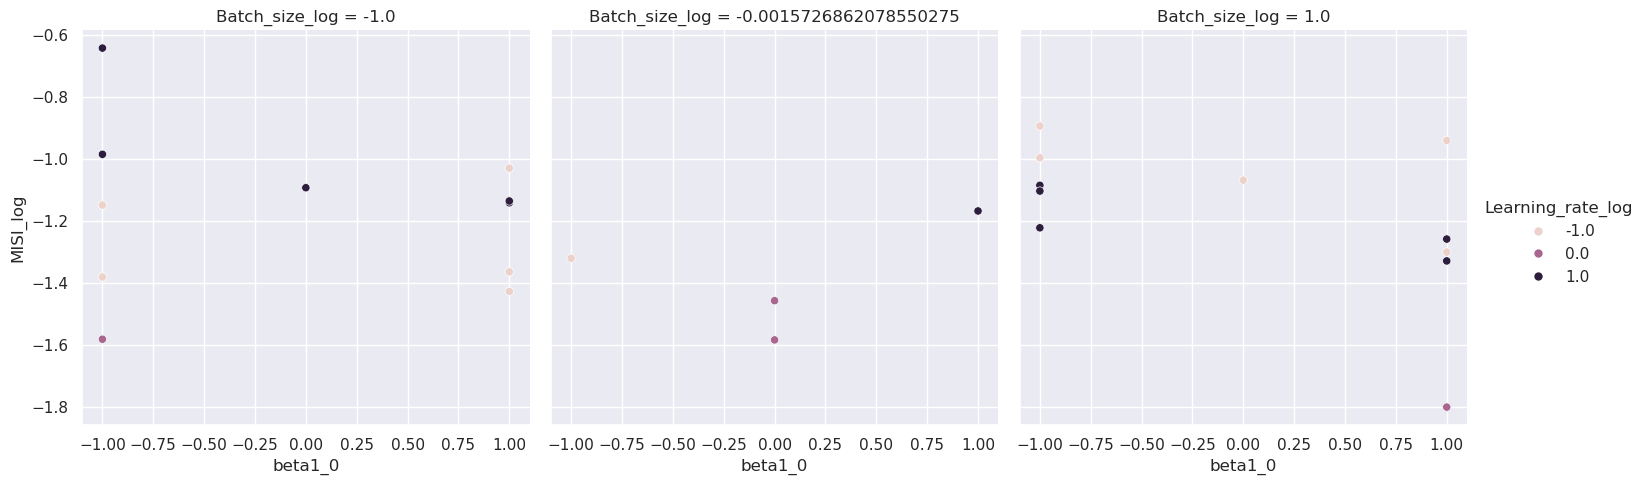

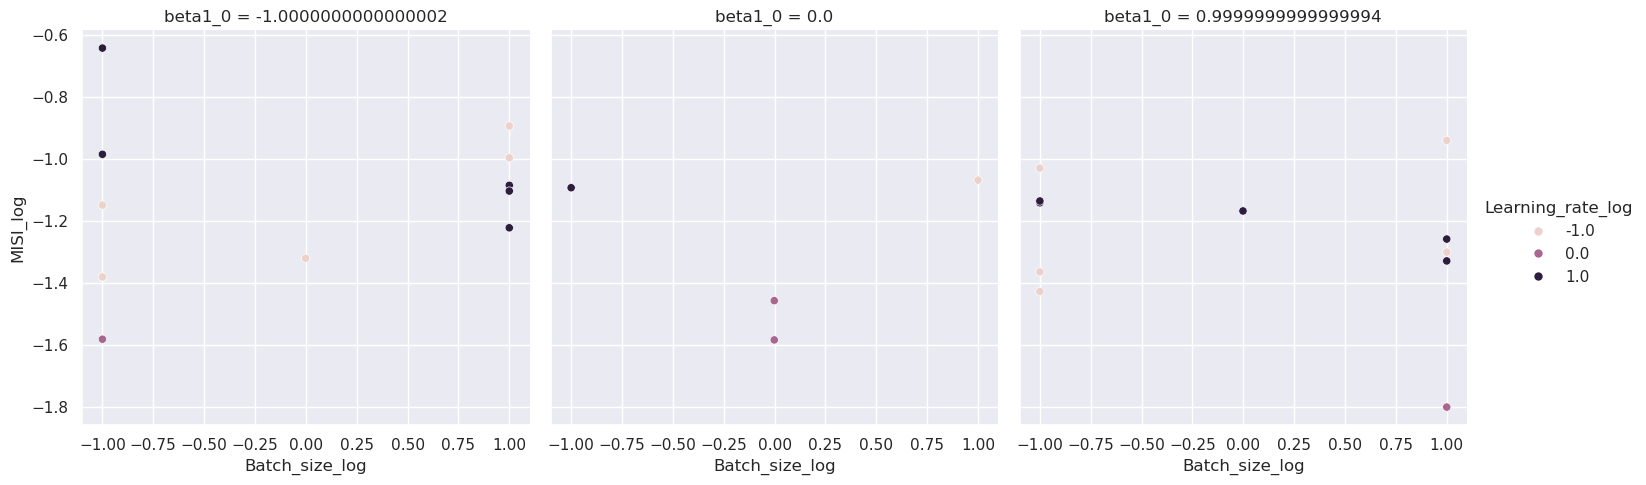

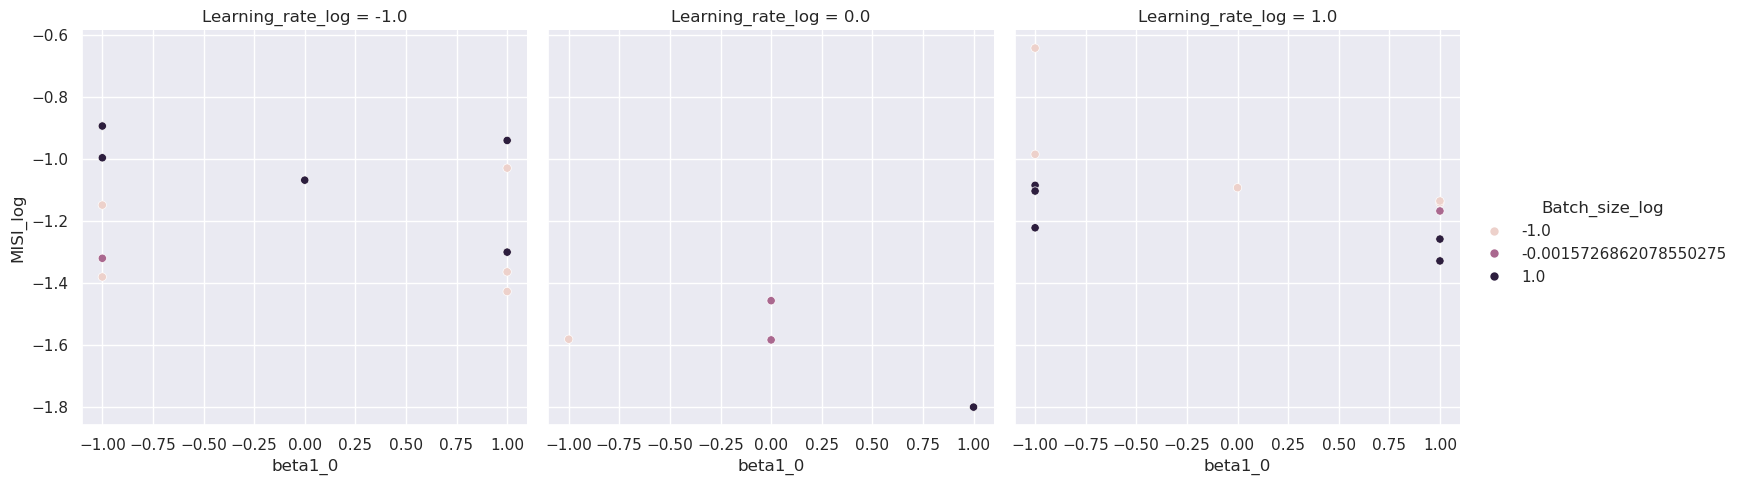

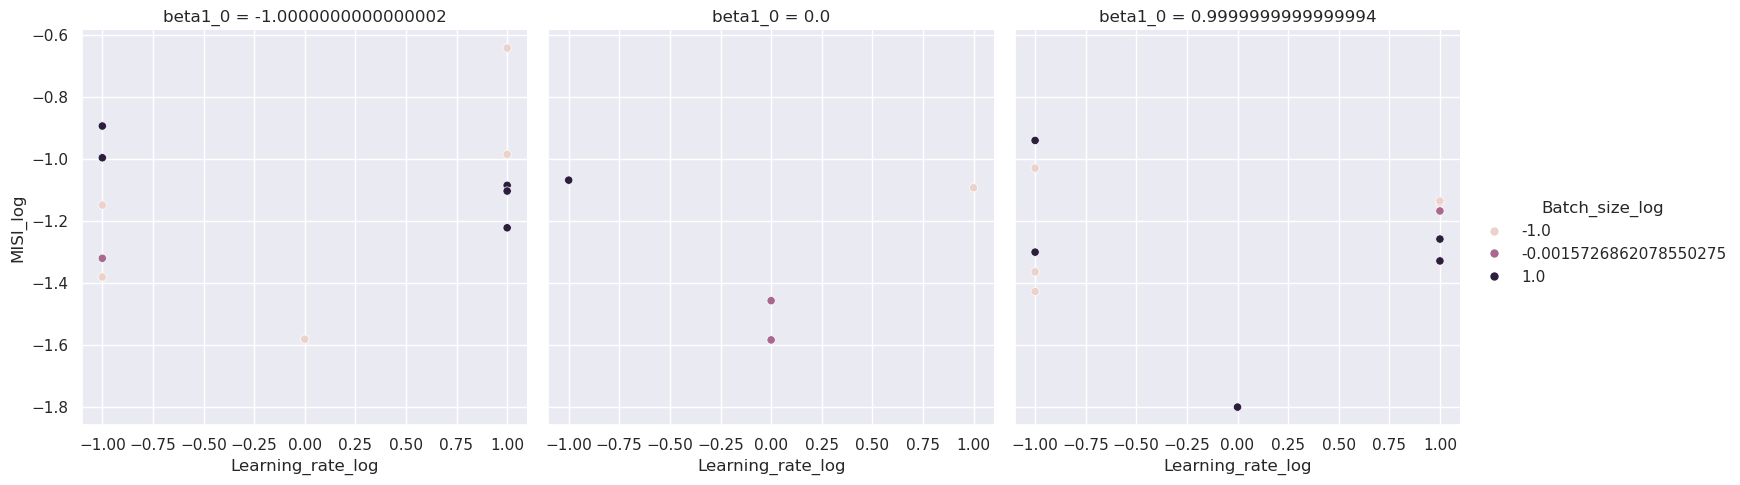

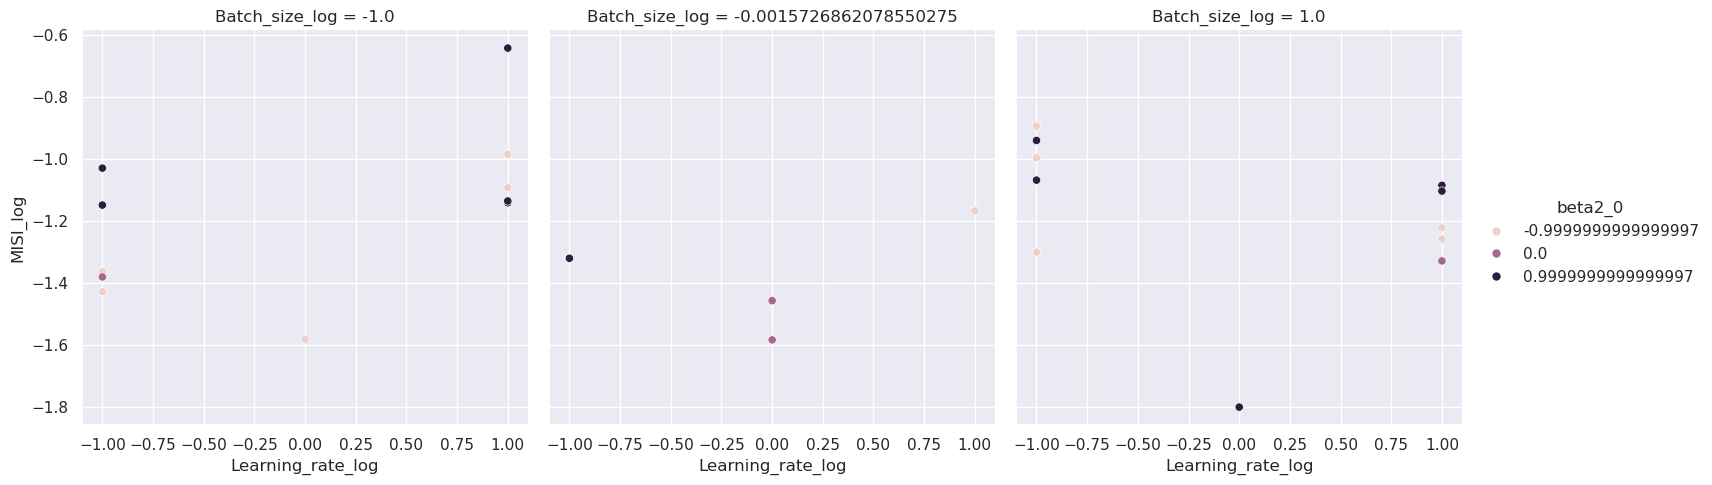

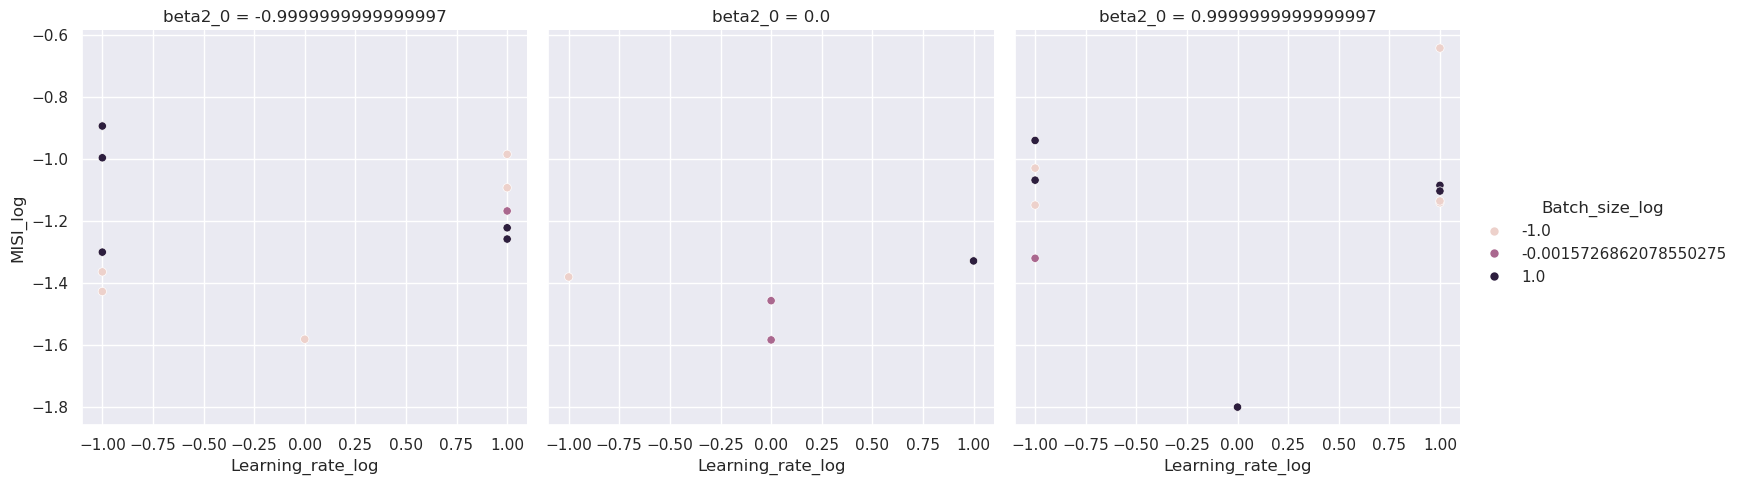

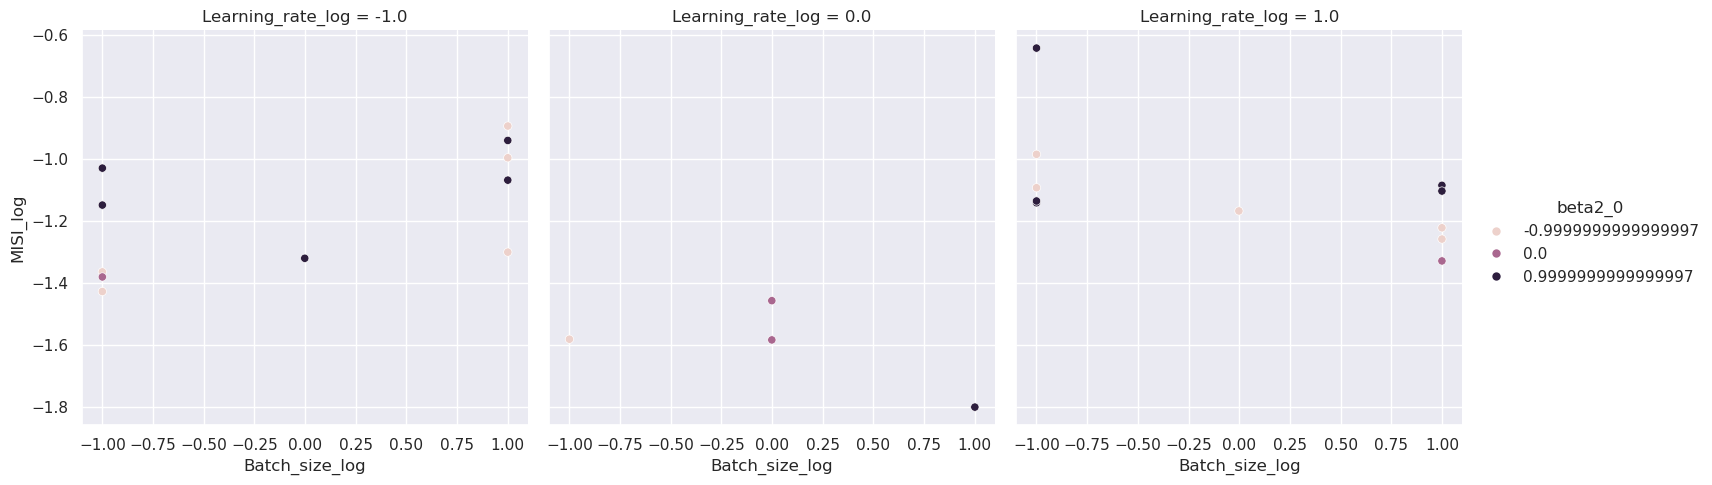

In [5]:
# Import seaborn
import seaborn as sns

# Apply the default theme
sns.set_theme()

# # Create a visualization
# sns.relplot(
#     data=mp_df,
#     x="beta2_0", y="run_time", col="Batch_size_log", row="GPU",
#     hue="LocalOS"
# )

# Create a visualization
sns.relplot(
    data=mp_df,
    x="beta2_0", y="MISI_log", col="Batch_size_log",
    hue="Learning_rate_log"
)

sns.relplot(
    data=mp_df,
    x="beta1_0", y="MISI_log", col="Batch_size_log",
    hue="Learning_rate_log"
)

sns.relplot(
    data=mp_df,
    x="Batch_size_log", y="MISI_log", col="beta1_0",
    hue="Learning_rate_log"
)

sns.relplot(
    data=mp_df,
    x="beta1_0", y="MISI_log", col="Learning_rate_log",
    hue="Batch_size_log"
)

sns.relplot(
    data=mp_df,
    x="Learning_rate_log", y="MISI_log", col="beta1_0",
    hue="Batch_size_log"
)

sns.relplot(
    data=mp_df,
    x="Learning_rate_log", y="MISI_log", col="Batch_size_log",
    hue="beta2_0"
)

sns.relplot(
    data=mp_df,
    x="Learning_rate_log", y="MISI_log", col="beta2_0",
    hue="Batch_size_log"
)

sns.relplot(
    data=mp_df,
    x="Batch_size_log", y="MISI_log", col="Learning_rate_log",
    hue="beta2_0"
)

In [6]:
# Quadratic function evaluation:

# Single vector input (x):
def f1v(x, A, b, c):
  return c + b.T @ x + x.T @ (A @ x)
# Multiple vector (matrix) input (x):
def f1m(x, A, b, c):
  return c + b.T @ x + np.sum(x * (A @ x), axis=0)

# Modified functions to impose bounds:
def f1v_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + x_clipped.T @ (A @ x_clipped)
def f1m_with_bounds(x, A, b, c, lower_bound, upper_bound):
    x_clipped = np.clip(x, lower_bound, upper_bound)
    return c + b.T @ x_clipped + np.sum(x_clipped * (A @ x_clipped), axis=0)



def boundary_solver_1var_1eq(x0, U, boundary_values=[-1,1], exclude_vars=None):

    counter = 0
    x_stars = []
    x_ixs = [i for i in range(len(x0)) if i not in exclude_vars]
    for x_ix in x_ixs:
        for boundary_value in boundary_values:
            counter += 1
            print(counter)

            e = U[x_ix]
            f = boundary_value - x0[x_ix]
            k = f / e

            x_star = x0[:,None] + k * U # optimal value at boundary

            if np.any((x_star - max(boundary_values)) > 2) or np.any((x_star - min(boundary_values) < -2)):
                print('OUT OF BOUNDS')
            else:
                x_stars.append([x_star,f1v(x_star, A, b, c)])

            print('x_star:\n{val}'.format(val=x_star.T))
            print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
            print()

    return x_stars

def boundary_solver_2vars_2eqs(x0, U, boundary_values=[-1,1], exclude_vars=None):

    counter = 0
    x_stars = []
    x_ixs = []
    # for ix, U in enumerate([U_neg, U_zero]):
        # if U.shape[1] == 1:
        #     x_ixs.append([[i] for i in range(offset[ix],offset[ix]+len(x0)) if i not in exclude_vars])
    if U.shape[1] == 2:
        x_ixs = [[i,j] for i in range(len(x0)) if i not in exclude_vars
                        for j in range(len(x0)) if j not in exclude_vars and j > i]
    elif U.shape[1] == 3:
        x_ixs = [[i,j,k] for i in range(len(x0)) if i not in exclude_vars
                        for j in range(len(x0)) if j not in exclude_vars and j > i
                        for k in range(len(x0)) if k not in exclude_vars and k > j]
    # x_ix = [i for i in range(len(x0)) if i not in exclude_vars]
    # x_ixs = []
    # x_ixs.append([x_ix[kk] for kk in range(U.shape[1])])
    # for kk in range(U.shape[1]):
    #     if kk == 0:
    #         x_ixs = [[i] for i in range(len(x0)) if i not in exclude_vars]
    #     else:
    #         x_ixs = [xx.append(i) for xx in x_ixs if i > x_ixs[-1]]
    print(x_ixs)
    # U = np.concatenate([U_neg, U_zero], axis=1)
    print(U)
    boundary_tuples = []
    if U.shape[1] == 2:
        boundary_tuples = [[i,j] for i in boundary_values for j in boundary_values]
    elif U.shape[1] == 3:
        boundary_tuples = [[i,j,k] for i in boundary_values for j in boundary_values for k in boundary_values]

    for x_ix in x_ixs:
        # for x_ix_zero in x_ixs[1]:
        # x_ix = (x_ix_neg + x_ix_zero).sort()
        # print(x_ix_neg + x_ix_zero)
        for boundary_tuple in boundary_tuples:
            counter += 1
            print(counter)

            print(f"U:\n{U}")

            e = U[x_ix, :]
            f = np.array(boundary_tuple) - x0[x_ix]
            k = np.linalg.pinv(e) @ f[:,None]

            x_star = x0[:,None] + U @ k # optimal value at boundaries

            if np.any((x_star - max(boundary_values)) > 2) or np.any((x_star - min(boundary_values) < -2)):
                print('OUT OF BOUNDS')
            else:
                x_stars.append([x_star,f1v(x_star, A, b, c)])

            print('x_star:\n{val}'.format(val=x_star.T))
            print("f1v at x_star (no bounds):", f1v(x_star, A, b, c))
            print()

    return x_stars

def optimize_quadratic_with_bounds(A, b, c, bounds):

    print('c:\n{val}'.format(val=c))
    print('b:\n{val}'.format(val=b))
    print('A:\n{val}'.format(val=A))
    print()

    # stationary point: solution of grad_f(A,b,c)_wrt_x = 0 --> A @ x + b = 0 --> x0 = inv(A) @ (-b)
    x0 = np.linalg.pinv(A) @ (-b)
    print('x0:\n{val}'.format(val=x0))
    print("f1v at x0 (no bounds):", f1v(x0, A, b, c))
    print()

    # Retrieve eigenvectors and eigenvalues of A to determine curvatures of the quadratic function
    D, U = np.linalg.eigh(A)
    print('Eigenvalues (D):\n{val}'.format(val=D))
    print('Eigenvectors (U):\n{val}'.format(val=U))
    print()

    # # Find cols of A that are all zeros:
    # zero_cols = np.where(np.sum(np.abs(A), axis=0) == 0)[0]
    # print('excluding vars:\n{val}'.format(val=zero_cols+1))
    # print()

    semi_negative_curvatures = (D <= 0) # np.logical_and((D < 0), (np.abs(D) > 1e-3))
    if sum(semi_negative_curvatures) == 1:
        # Only 1 direction with negative curvature
        x_stars = boundary_solver_1var_1eq(x0, U[:,semi_negative_curvatures], boundary_values=bounds, exclude_vars=[])#zero_cols)
    elif sum(semi_negative_curvatures) == 0:
        # x0 is the minimum
        x_stars = [x0]
    else:
        # Multiple directions with negative curvature
        x_stars = boundary_solver_2vars_2eqs(x0, U[:,semi_negative_curvatures], boundary_values=bounds, exclude_vars=[])#zero_cols)


    return x_stars


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def brute_force_quadratic_minimum(A, b, c):

    x = [np.arange(0,2.02,.02)-1 for dd in range(A.shape[0])]

    # X1, X2, X3, X4 = np.meshgrid(x[0], x[1], x[2], x[3])
    XD = [*np.meshgrid(*x)]
    X = np.concatenate([xx.reshape(-1,1) for xx in XD], axis=1)

    Y = c + X @ b + np.sum((X @ A) * X, axis=1)
    # Y = Y.reshape(X1.shape[0], X1.shape[1], X1.shape[2], X1.shape[3])
    Y = Y.reshape(*(XD[0].shape))

    # Minimum of the function ON THE GRID:
    min_idx = np.argmin(Y)
    min_idx = np.unravel_index(min_idx, Y.shape)

    return np.array([xx[min_idx] for xx in XD]), Y[min_idx]

def make_quadratic_contour_plots(A, b, c, lock, names, x_stars):

    keep = [kk for kk in range(A.shape[0]) if kk not in lock]

    x = [np.arange(0,2.01,.01)-1 if dd not in lock else np.round(x_stars[0][0][dd],2)*np.ones(1) for dd in range(A.shape[0])]
    GR_max = np.array([max([max(xx) for xx in x])])
    GR_min = np.array([min([min(xx) for xx in x])])

    # X1, X2, X3, X4 = np.meshgrid(x[0], x[1], x[2], x[3])
    XD = [*np.meshgrid(*x)]
    X = np.concatenate([xx.reshape(-1,1) for xx in XD], axis=1)

    Y = c + X @ b + np.sum((X @ A) * X, axis=1)
    # Y = Y.reshape(X1.shape[0], X1.shape[1], X1.shape[2], X1.shape[3])
    Y = Y.reshape(*(XD[0].shape))

    # Minimum of the function ON THE GRID:
    min_idx = np.argmin(Y)
    min_idx = np.unravel_index(min_idx, Y.shape)

    xsk2_vals = [np.round(x_stars[ss][0][keep[2]], decimals=2) for ss in range(len(x_stars))]
    x[keep[2]] = np.unique(np.concatenate(xsk2_vals + [GR_min, np.zeros(1), GR_max]))

    # enforce the  same colormap for all subplots:
    vmin = np.min(Y)
    vmax = np.max(Y)

    lock_slice = tuple(slice(None) if i not in lock else 0 for i in range(XD[0].ndim))
    lock_names = [f"{names[ll]} = 0" for ll in lock]
    fig, axs = plt.subplots(max(1,len(x[keep[2]])//5), min(len(x[keep[2]]),5), figsize=(15, max(1,len(x[keep[2]])//5)*5))
    for ix, val in enumerate(x[keep[2]]):
        ax = axs[ix]
        CS = ax.contour(XD[keep[0]][lock_slice][:,:,ix], XD[keep[1]][lock_slice][:,:,ix], Y[lock_slice][:,:,ix], vmin=vmin, vmax=vmax)
        ax.clabel(CS, inline=1, fontsize=10)
        ax.set_title(f"{names[keep[2]]} = {x[keep[2]][ix]}\n" + ', '.join(lock_names))
        ax.set_xlabel(names[keep[0]])
        if ix == 0:
            ax.set_ylabel(names[keep[1]])
        if round(XD[keep[2]][min_idx].item(),2) == val:
            ax.scatter(XD[keep[0]][min_idx], XD[keep[1]][min_idx], c='b', marker='o')
            if XD[keep[1]][min_idx] < 0:
                ax.annotate(f"{round(Y[min_idx].item(),2)}", (XD[keep[0]][min_idx], XD[keep[1]][min_idx]), textcoords="offset points", xytext=(0,10), ha='center')
            else:
                ax.annotate(f"{round(Y[min_idx].item(),2)}", (XD[keep[0]][min_idx], XD[keep[1]][min_idx]), textcoords="offset points", xytext=(0,-10), ha='center')
        for x_star in x_stars:
            if round(x_star[0][keep[2]].item(),2) == val:
                ax.scatter(x_star[0][keep[0]], x_star[0][keep[1]], c='r', marker='*')
                # Annotate the point with a value, making sure text does not spill outside of plot area:
                if x_star[0][keep[1]] < 0:
                    ax.annotate(f"{round(x_star[1].item(),2)}", (x_star[0][keep[0]], x_star[0][keep[1]]), textcoords="offset points", xytext=(0,10), ha='center')
                else:
                    ax.annotate(f"{round(x_star[1].item(),2)}", (x_star[0][keep[0]], x_star[0][keep[1]]), textcoords="offset points", xytext=(0,-20), ha='center')


    return XD, Y, axs

def make_quadratic_contour_plots2(A, b, c, lock, names, x_stars):

    keep = [kk for kk in range(A.shape[0]) if kk not in lock]

    x = [np.arange(0,2.01,.01)-1 if dd not in lock else np.round(x_stars[0][0][dd],2)*np.ones(1) for dd in range(A.shape[0])]
    GR_max = np.array([max([max(xx) for xx in x])])
    GR_min = np.array([min([min(xx) for xx in x])])

    # X1, X2, X3, X4 = np.meshgrid(x[0], x[1], x[2], x[3])
    XD = [*np.meshgrid(*x)]
    X = np.concatenate([xx.reshape(-1,1) for xx in XD], axis=1)

    Y = c + X @ b + np.sum((X @ A) * X, axis=1)
    # Y = Y.reshape(X1.shape[0], X1.shape[1], X1.shape[2], X1.shape[3])
    Y = Y.reshape(*(XD[0].shape))

    # Minimum of the function ON THE GRID:
    min_idx = np.argmin(Y)
    min_idx = np.unravel_index(min_idx, Y.shape)

    # xsk2_vals = [np.round(x_stars[ss][0][keep[2]], decimals=2) for ss in range(len(x_stars))]
    # x[keep[2]] = np.unique(np.concatenate(xsk2_vals + [GR_min, np.zeros(1), GR_max]))

    # enforce the  same colormap for all subplots:
    vmin = np.min(Y)
    vmax = np.max(Y)

    lock_slice = tuple(slice(None) if i not in lock else 0 for i in range(XD[0].ndim))
    lock_names = [f"{names[ll]} = {np.round(x_stars[0][0][ll],2)}" for ll in lock]
    fig, axs = plt.subplots(max(1,1//5), min(1,5), figsize=(1*5, max(1,1//5)*6.25))
    for ix, val in enumerate(x[lock[0]]):
        ax = axs
        CS = ax.contour(XD[keep[0]][lock_slice][:,:], XD[keep[1]][lock_slice][:,:], Y[lock_slice][:,:], vmin=vmin, vmax=vmax, levels=5, cmap='viridis')
        ax.clabel(CS, inline=1, fontsize=24)
        ax.axis('square')
        ax.tick_params(axis='both', labelsize=18)
        ax.set_title('\n'.join(lock_names), fontsize=20)
        ax.set_xlabel(names[keep[0]], fontsize=24)
        if ix == 0:
            ax.set_ylabel(names[keep[1]], fontsize=24)
        if round(XD[lock[0]][min_idx].item(),2) == val:
            ax.scatter(XD[keep[0]][min_idx], XD[keep[1]][min_idx], c='r', marker='o')
            if XD[keep[1]][min_idx] < 0:
                ax.annotate(f"{round(Y[min_idx].item(),2)}", (XD[keep[0]][min_idx], XD[keep[1]][min_idx]), textcoords="offset points", xytext=(0,16), ha='center', color='r', fontsize=24)
            else:
                ax.annotate(f"{round(Y[min_idx].item(),2)}", (XD[keep[0]][min_idx], XD[keep[1]][min_idx]), textcoords="offset points", xytext=(0,-16), ha='center', color='r', fontsize=24)


    return XD, Y, axs, fig

In [8]:
# from google.colab import drive
# drive.mount('/content/drive')

In [9]:
x_stars = {}

                            OLS Regression Results                            
Dep. Variable:               MISI_log   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     5.128
Date:                Wed, 24 Sep 2025   Prob (F-statistic):            0.00242
Time:                        22:47:23   Log-Likelihood:                 19.312
No. Observations:                  26   AIC:                            -16.62
Df Residuals:                      15   BIC:                            -2.785
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

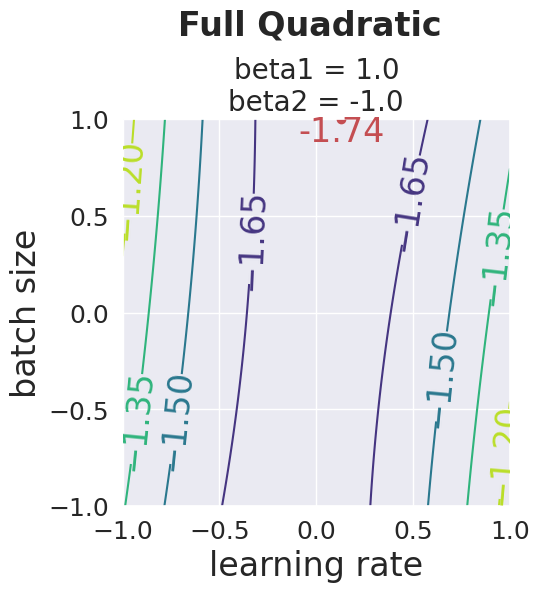

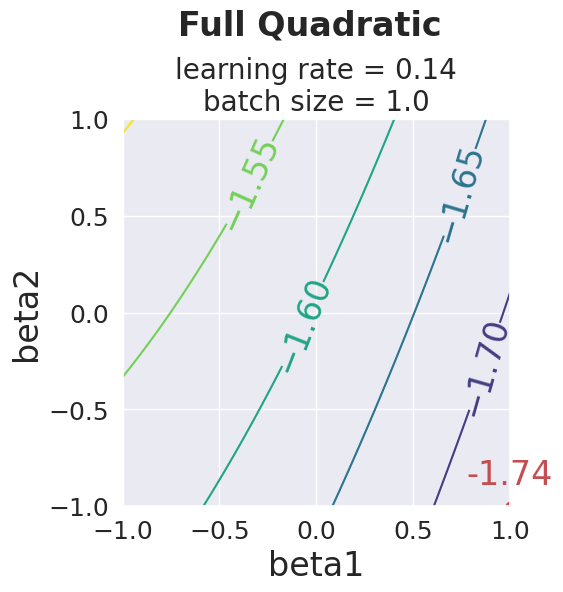

0.021380525140986137


In [10]:
# MISI (all)
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('MISI_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 + ' +
                         'Learning_rate_log:Batch_size_log + beta1_0:Learning_rate_log + Batch_size_log:beta1_0 + ' +
                         'I(Learning_rate_log**2) + I(beta1_0**2) + I(Batch_size_log**2)',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[lrm_mp.params['I(Learning_rate_log ** 2)'], (lrm_mp.params['Learning_rate_log:Batch_size_log']/2), (lrm_mp.params['beta1_0:Learning_rate_log']/2), 0],
              [(lrm_mp.params['Learning_rate_log:Batch_size_log']/2), lrm_mp.params['I(Batch_size_log ** 2)'], (lrm_mp.params['Batch_size_log:beta1_0']/2), 0],
              [(lrm_mp.params['beta1_0:Learning_rate_log']/2), (lrm_mp.params['Batch_size_log:beta1_0']/2), lrm_mp.params['I(beta1_0 ** 2)'], 0],
              [0, 0, 0, 0]])

# x_stars['MISI_full'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])
# # print(x_stars)

# names = ['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']
# # lock = [3]
# lock = []

# XD, Y, axs = make_quadratic_contour_plots(A, b, c, lock, names, x_stars['MISI_full'])

x_star, y_star = brute_force_quadratic_minimum(A, b, c)
print(f"x_star:\n{x_star}")
print(f"y_star:\n{10**y_star}")
x_stars['MISI_full'] = x_star

# plt.show()

print(f'MISI_full: {10**f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MISI_sig: {10**f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_full: {10**f1v(np.array([ 0.58,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_sig: {10**f1v(np.array([ 0.54,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'Epoch_full: {10**f1v(np.array([ 1.  , -1.  ,  0.46, -1.  ]),A,b,c)}')
print(f'Epoch_sig: {10**f1v(np.array([ 1., -1.,  1., -1.]),A,b,c)}')

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[np.array([ 0.14,  1.  ,  1.  , -1.  ]),f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{MISI} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullMISI1.pdf', dpi=800, bbox_inches='tight') left
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2aleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[np.array([ 0.14,  1.  ,  1.  , -1.  ]),f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{MISI} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullMISI2.pdf', dpi=800, bbox_inches='tight') right
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2aright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.0093, 300, 0.9233, 0.8700])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)

                            OLS Regression Results                            
Dep. Variable:               MISI_log   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     9.292
Date:                Wed, 24 Sep 2025   Prob (F-statistic):           8.00e-05
Time:                        22:48:15   Log-Likelihood:                 17.802
No. Observations:                  26   AIC:                            -21.60
Df Residuals:                      19   BIC:                            -12.80
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

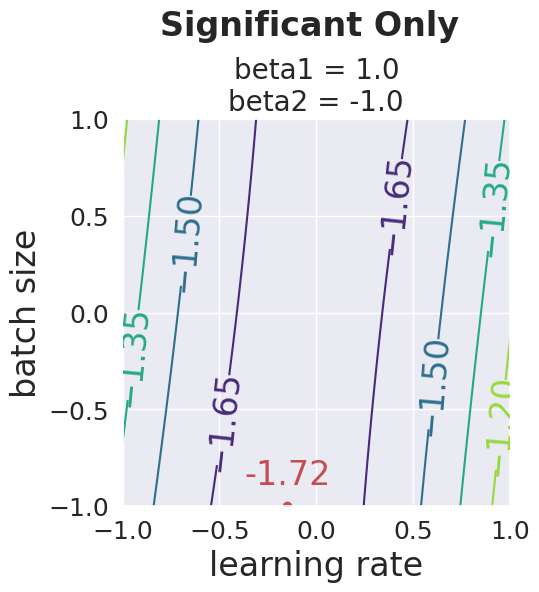

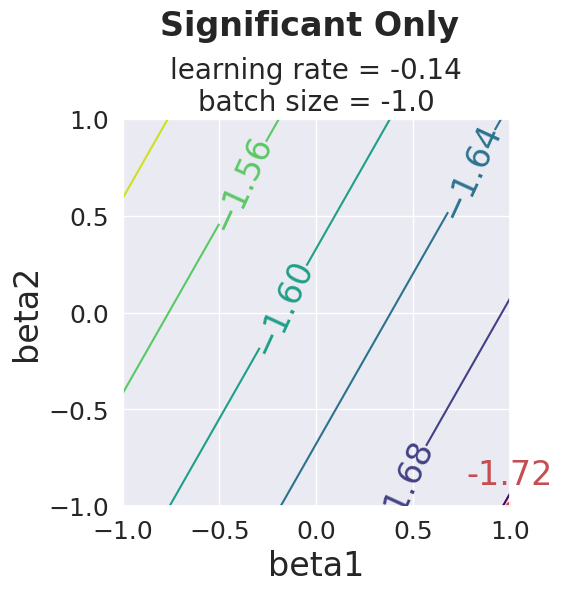

0.020640282752361908


In [11]:
# MISI (only significant)
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('MISI_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 + ' +
                         'Learning_rate_log:Batch_size_log + ' +
                         'I(Learning_rate_log**2)',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[lrm_mp.params['I(Learning_rate_log ** 2)'], (lrm_mp.params['Learning_rate_log:Batch_size_log']/2), 0, 0],
              [lrm_mp.params['Learning_rate_log:Batch_size_log']/2, 0 , 0 , 0],
              [0, 0, 0, 0],
              [0, 0, 0, 0]])

x_star, y_star = brute_force_quadratic_minimum(A, b, c)
print(f"x_star:\n{x_star}")
print(f"y_star:\n{10**y_star}")
x_stars['MISI_sig'] = x_star

# x_stars['MISI_sig'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])

# names = ['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']
# lock = [3]

# XD, Y, axs = make_quadratic_contour_plots(A, b, c, lock, names, x_stars['MISI_sig'])

# plt.show()

print(f'MISI_full: {10**f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MISI_sig: {10**f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_full: {10**f1v(np.array([ 0.58,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_sig: {10**f1v(np.array([ 0.54,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'Epoch_full: {10**f1v(np.array([ 1.  , -1.  ,  0.46, -1.  ]),A,b,c)}')
print(f'Epoch_sig: {10**f1v(np.array([ 1., -1.,  1., -1.]),A,b,c)}')

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[np.array([-0.14, -1.  ,  1.  , -1.  ]),f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{MISI} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigMISI1.pdf', dpi=800, bbox_inches='tight')
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2dleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[np.array([-0.14, -1.  ,  1.  , -1.  ]),f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{MISI} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigMISI2.pdf', dpi=800, bbox_inches='tight')
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2dright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.0070, 200, 0.9500, 0.8700])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)

                            OLS Regression Results                            
Dep. Variable:                MxE_log   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     9.462
Date:                Wed, 24 Sep 2025   Prob (F-statistic):           8.08e-05
Time:                        22:49:04   Log-Likelihood:                 8.8627
No. Observations:                  26   AIC:                             4.275
Df Residuals:                      15   BIC:                             18.11
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

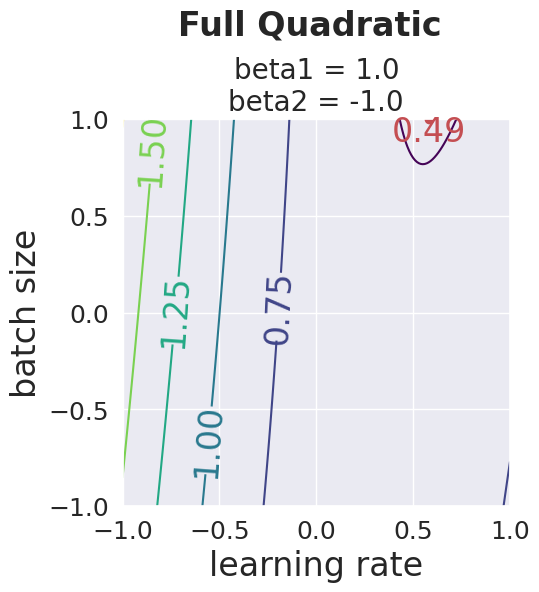

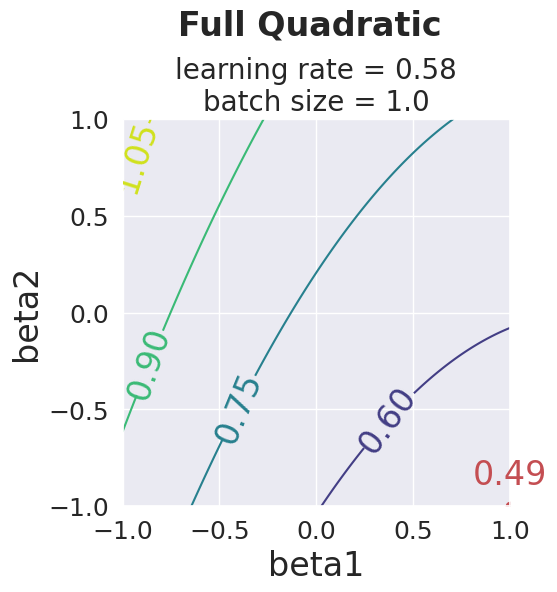

3.8189077213606075


In [12]:
# 10/31 - MxE Full
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('MxE_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 +' +
                         'Learning_rate_log*Batch_size_log + Learning_rate_log*beta1_0 + Batch_size_log*beta1_0 + ' +
                         'I(Learning_rate_log**2) + I(beta1_0**2) + I(Batch_size_log**2) ',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[lrm_mp.params['I(Learning_rate_log ** 2)'], (lrm_mp.params['Learning_rate_log:Batch_size_log']/2), (lrm_mp.params['Learning_rate_log:beta1_0']/2), 0],
              [(lrm_mp.params['Learning_rate_log:Batch_size_log']/2), lrm_mp.params['I(Batch_size_log ** 2)'], (lrm_mp.params['Batch_size_log:beta1_0']/2), 0],
              [(lrm_mp.params['Learning_rate_log:beta1_0']/2), (lrm_mp.params['Batch_size_log:beta1_0']/2), lrm_mp.params['I(beta1_0 ** 2)'], 0],
              [0, 0, 0, 0]])

x_star, y_star = brute_force_quadratic_minimum(A, b, c)
print(f"x_star:\n{x_star}")
print(f"y_star:\n{10**y_star}")
print(y_star)
x_stars['MxE_full'] = x_star


# x_stars['MxE_full'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])

x_plot = np.array([ 0.58,  1.  ,  1.  , -1.  ])

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{M \times E} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullMxE1.pdf', dpi=800, bbox_inches='tight')
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2bleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{M \times E} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullMxE2.pdf', dpi=800, bbox_inches='tight')
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2bright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.0290, 300, 0.95,0.8484])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)

                            OLS Regression Results                            
Dep. Variable:                MxE_log   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     15.95
Date:                Wed, 24 Sep 2025   Prob (F-statistic):           1.56e-06
Time:                        22:49:30   Log-Likelihood:                 8.6728
No. Observations:                  26   AIC:                            -1.346
Df Residuals:                      18   BIC:                             8.719
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

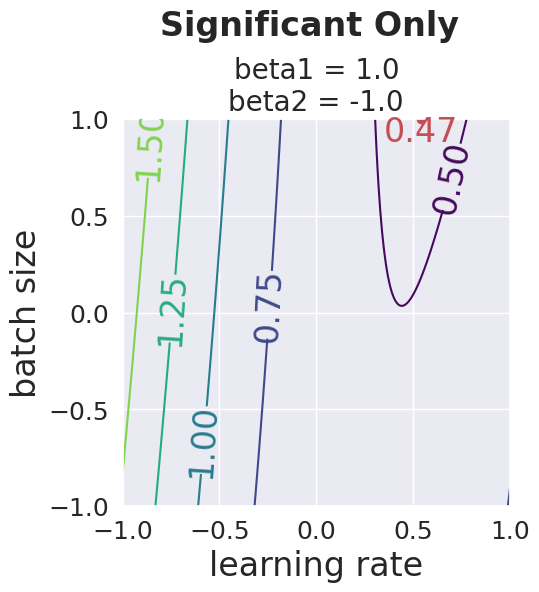

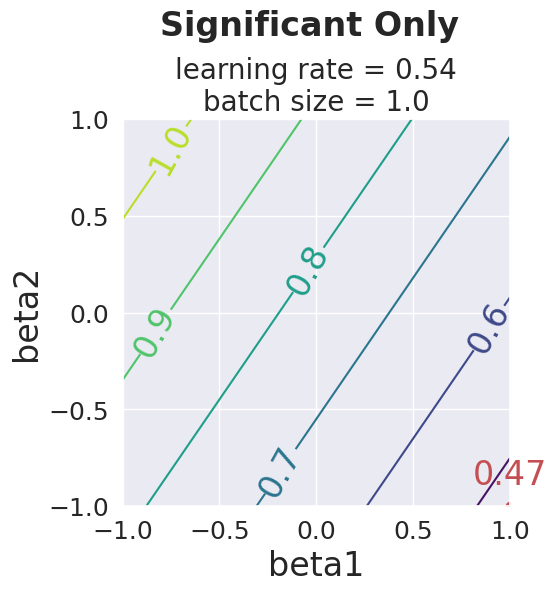

3.173335648752897


In [13]:
# 10/31 - MxE (Sig. only))
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('MxE_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 +' +
                         'Learning_rate_log*Batch_size_log + Learning_rate_log*beta1_0 + ' +
                         'I(Learning_rate_log**2)',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[lrm_mp.params['I(Learning_rate_log ** 2)'], (lrm_mp.params['Learning_rate_log:Batch_size_log']/2), (lrm_mp.params['Learning_rate_log:beta1_0']/2), 0],
              [(lrm_mp.params['Learning_rate_log:Batch_size_log']/2), 0, 0, 0],
              [(lrm_mp.params['Learning_rate_log:beta1_0']/2), 0, 0, 0],
              [0, 0, 0, 0]])

x_star, y_star = brute_force_quadratic_minimum(A, b, c)
print(f"x_star:\n{x_star}")
print(f"y_star:\n{10**y_star}")
x_stars['MxE_sig'] = x_star

# x_stars['MxE_sig'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])

x_plot = np.array([ 0.54,  1.  ,  1.  , -1.  ])

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{M \times E} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigMxE1.pdf', dpi=800, bbox_inches='tight')
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2eleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{M \times E} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigMxE2.pdf', dpi=800, bbox_inches='tight')
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2eright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.0265, 300, 0.9500, 0.8100])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)

                            OLS Regression Results                            
Dep. Variable:              Epoch_log   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     31.39
Date:                Wed, 24 Sep 2025   Prob (F-statistic):           3.02e-08
Time:                        22:49:46   Log-Likelihood:                 27.724
No. Observations:                  26   AIC:                            -33.45
Df Residuals:                      15   BIC:                            -19.61
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

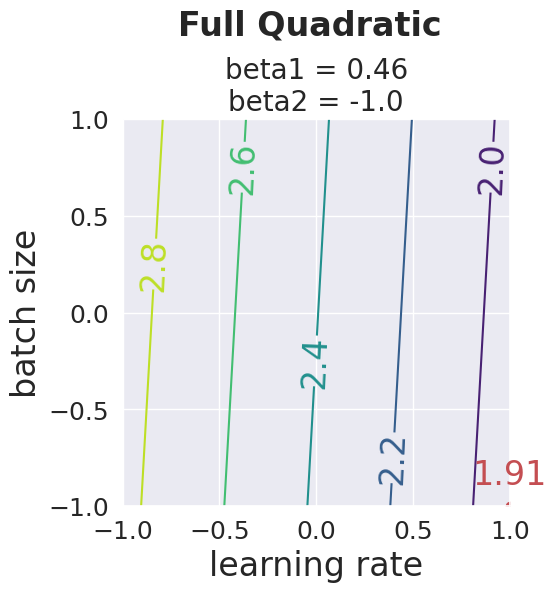

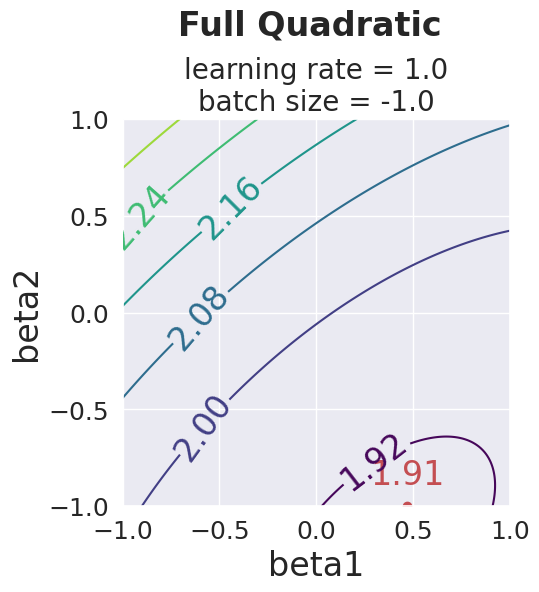

85.85801029714843


In [14]:
# Epoch (full model)
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('Epoch_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 + ' +
                         'Learning_rate_log:beta1_0 + Learning_rate_log:beta2_0 + ' +
                         'beta1_0:beta2_0 + ' +
                         'I(Learning_rate_log**2) + I(beta1_0**2) + I(beta2_0**2)',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[lrm_mp.params['I(Learning_rate_log ** 2)'], 0, (lrm_mp.params['Learning_rate_log:beta1_0']/2), (lrm_mp.params['Learning_rate_log:beta2_0']/2)],
              [0, 0, 0, 0],
              [(lrm_mp.params['Learning_rate_log:beta1_0']/2), 0, lrm_mp.params['I(beta1_0 ** 2)'], (lrm_mp.params['beta1_0:beta2_0']/2)],
              [(lrm_mp.params['Learning_rate_log:beta2_0']/2), 0, (lrm_mp.params['beta1_0:beta2_0']/2), lrm_mp.params['I(beta2_0 ** 2)']]])

x_star, y_star = brute_force_quadratic_minimum(A, b, c)
print(f"x_star:\n{x_star}")
print(f"y_star:\n{10**y_star}")
x_stars['Epoch_full'] = x_star

# x_stars['Epoch_full'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])

'''{'MISI_full': array([ 0.14,  1.  ,  1.  , -1.  ]),
 'MISI_sig': array([-0.14, -1.  ,  1.  , -1.  ]),
 'MxE_full': array([ 0.58,  1.  ,  1.  , -1.  ]),
 'MxE_sig': array([ 0.54,  1.  ,  1.  , -1.  ]),
 'Epoch_full': array([ 1.  , -1.  ,  0.46, -1.  ]),
 'Epoch_sig': array([ 1., -1.,  1., -1.])}
 '''

print(f'MISI_full: {10**f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MISI_sig: {10**f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_full: {10**f1v(np.array([ 0.58,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_sig: {10**f1v(np.array([ 0.54,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'Epoch_full: {10**f1v(np.array([ 1.  , -1.  ,  0.46, -1.  ]),A,b,c)}')
print(f'Epoch_sig: {10**f1v(np.array([ 1., -1.,  1., -1.]),A,b,c)}')

x_plot = np.array([ 1.  , -1.  ,  0.46, -1.  ])

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{Epochs} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullEpoch1.pdf', dpi=800, bbox_inches='tight')
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2cleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'  $\mathrm{log}_{10} \left( \mathrm{Epochs} \right)$ (Full Quadratic)  ', fontsize=24, fontweight='bold')
fig.suptitle(r'Full Quadratic', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/FullEpoch2.pdf', dpi=800, bbox_inches='tight')
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2cright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.1000, 200, 0.8990, 0.8154])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)

                            OLS Regression Results                            
Dep. Variable:              Epoch_log   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     48.05
Date:                Wed, 24 Sep 2025   Prob (F-statistic):           2.27e-10
Time:                        22:51:02   Log-Likelihood:                 26.322
No. Observations:                  26   AIC:                            -36.64
Df Residuals:                      18   BIC:                            -26.58
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

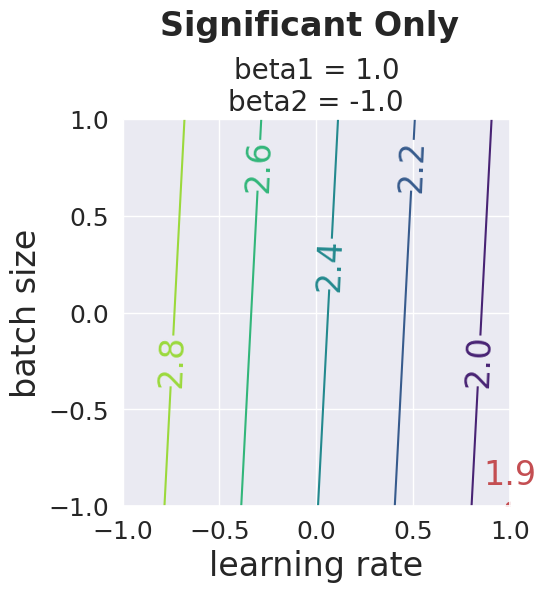

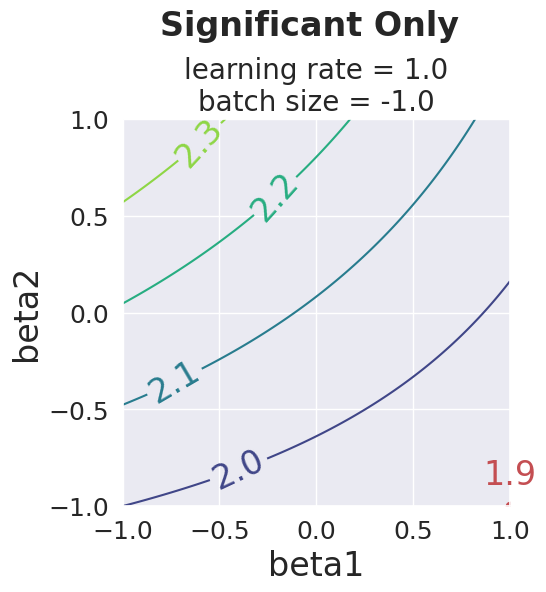

85.32810029045714


In [15]:
# Epoch (sig. only)
from patsy import dmatrices
import statsmodels.api as sm

# Modified formula: fewer interaction terms and a transformation
target, data = dmatrices('Epoch_log ~ Learning_rate_log + Batch_size_log + beta1_0 + beta2_0 + ' +
                         'Learning_rate_log:beta1_0 + Learning_rate_log:beta2_0 + ' +
                         'beta1_0:beta2_0',
                         data=mp_df, return_type='dataframe')

# Fit the model
lrm_mp = sm.OLS(target, data).fit()
print(lrm_mp.summary())


# Extract coefficients from lrm_mp to form quadratic function parameters:
c = lrm_mp.params['Intercept']
b = lrm_mp.params[['Learning_rate_log', 'Batch_size_log', 'beta1_0', 'beta2_0']].to_numpy()
A = np.array([[0, 0, (lrm_mp.params['Learning_rate_log:beta1_0']/2), (lrm_mp.params['Learning_rate_log:beta2_0']/2)],
              [0, 0, 0, 0],
              [(lrm_mp.params['Learning_rate_log:beta1_0']/2), 0, 0, (lrm_mp.params['beta1_0:beta2_0']/2)],
              [(lrm_mp.params['Learning_rate_log:beta2_0']/2), 0, (lrm_mp.params['beta1_0:beta2_0']/2), 0]])

x_star, y_star = brute_force_quadratic_minimum(A, b, c)
print(f"x_star:\n{x_star}")
print(f"y_star:\n{10**y_star}")
x_stars['Epoch_sig'] = x_star

# x_stars['Epoch_sig'] = optimize_quadratic_with_bounds(A, b, c, [-1,1])

print(f'MISI_full: {10**f1v(np.array([ 0.14,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MISI_sig: {10**f1v(np.array([-0.14, -1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_full: {10**f1v(np.array([ 0.58,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'MxE_sig: {10**f1v(np.array([ 0.54,  1.  ,  1.  , -1.  ]),A,b,c)}')
print(f'Epoch_full: {10**f1v(np.array([ 1.  , -1.  ,  0.46, -1.  ]),A,b,c)}')
print(f'Epoch_sig: {10**f1v(np.array([ 1., -1.,  1., -1.]),A,b,c)}')

x_plot = np.array([ 1., -1.,  1., -1.])

names = ['learning rate', 'batch size', 'beta1', 'beta2']
lock = [2, 3]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{Epochs} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigEpoch1.pdf', dpi=800, bbox_inches='tight')
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2fleft.pdf', dpi=800, bbox_inches='tight')

lock = [0, 1]
XD, Y, axs, fig = make_quadratic_contour_plots2(A, b, c, lock, names, [[x_plot,f1v(x_plot,A,b,c)]])
# Title for figure:
# fig.suptitle(r'$\mathrm{log}_{10} \left( \mathrm{Epochs} \right)$ (Significant Only)', fontsize=24, fontweight='bold')
fig.suptitle(r'Significant Only', fontsize=24, fontweight='bold')
plt.show()
# fig.savefig('/content/drive/MyDrive/HyperTorchMISA/SigEpoch2.pdf', dpi=800, bbox_inches='tight')
fig.savefig('/data/users3/rsilva/MISA-pytorch/figures/yohan2fright.pdf', dpi=800, bbox_inches='tight')

# average y
avg_x_star = np.array([0.1000, 200, 0.9190, 0.8100])
avg_x_star[0] = np.log10(avg_x_star[0]) - (-2.0)
avg_x_star[1] = np.log10(avg_x_star[1]) - 2.5
avg_x_star[2] = 2 * (avg_x_star[2] - 0.8) / .30
avg_x_star[3]= 2 * (avg_x_star[3] - 0.9) / .18

f1m(avg_x_star, A, b, c)
avg_y = 10**f1m(avg_x_star, A, b, c)
print(avg_y)